# 07 — Model Evaluation

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**  
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 1.0

---

## Objectives

Deep evaluation of Phase 6 trained models using held-out test data (2023–2025):

1. **Extended metrics** — RMSE, MAE, R², Directional Accuracy, IC, Hit Rate by quintile
2. **Error analysis** — residual patterns, heteroskedasticity, autocorrelation
3. **Regime analysis** — performance breakdown by VIX regime and event density
4. **SHAP deep-dive** — force plots, dependence plots, interaction effects
5. **Feature stability** — SHAP stability across time windows
6. **Publication figures** — 07a–07d for the dissertation

**Inputs:** `test_predictions.parquet`, `shap_values.parquet`, `model_comparison.parquet`, `model_features.parquet`  
**Outputs:** `evaluation_summary.parquet`, figures `07a`–`07d`

In [1]:
import os, sys, warnings, pickle, json
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.stats import norm, jarque_bera, shapiro
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import seaborn as sns

import shap
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Lasso

pd.set_option('display.float_format', '{:.5f}'.format)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT   = Path('..').resolve()
PROC   = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
FIGS   = ROOT / 'reports' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10,
})
PALETTE = ['#1f4e79', '#c55a11', '#70ad47', '#7030a0', '#d4a017']

print('✓ Imports complete')

✓ Imports complete


---
## Section 1 — Load Data

In [2]:
# ── Predictions ────────────────────────────────────────────────────────────────
preds_df = pd.read_parquet(PROC / 'test_predictions.parquet')
preds_df['date'] = pd.to_datetime(preds_df['date'])

# ── SHAP values ────────────────────────────────────────────────────────────────
shap_df = pd.read_parquet(PROC / 'shap_values.parquet')
shap_df['date'] = pd.to_datetime(shap_df['date'])
SHAP_FEATURES = [c for c in shap_df.columns if c != 'date']

# ── Model comparison ───────────────────────────────────────────────────────────
comp_df = pd.read_parquet(PROC / 'model_comparison.parquet')

# ── Feature metadata ───────────────────────────────────────────────────────────
feat_meta = pd.read_parquet(PROC / 'feature_metadata.parquet')
SELECTED_FEATURES = feat_meta[feat_meta['selected']]['feature'].tolist()

# ── Full feature matrix (for regime info) ─────────────────────────────────────
feat_df = pd.read_parquet(PROC / 'model_features.parquet')
feat_df['date'] = pd.to_datetime(feat_df['date'])

# ── Model metadata ─────────────────────────────────────────────────────────────
with open(MODELS / 'model_metadata.json') as f:
    meta = json.load(f)
BEST_MODEL_NAME = meta['best_model']
TRAIN_CUTOFF    = meta['train_cutoff']

# ── Test slice of feature matrix ──────────────────────────────────────────────
test_feat = feat_df[feat_df['date'] > TRAIN_CUTOFF].copy().reset_index(drop=True)

# ── Merge regime info into preds ──────────────────────────────────────────────
preds_df = preds_df.merge(
    test_feat[['date', 'vix_regime', 'high_vol_regime', 'vix', 'total_events']],
    on='date', how='left'
)

print(f'Test predictions : {preds_df.shape[0]:,} rows')
print(f'SHAP features    : {len(SHAP_FEATURES)}')
print(f'Best model       : {BEST_MODEL_NAME}')
print(f'Test period      : {preds_df["date"].min().date()} → {preds_df["date"].max().date()}')

# ── Short-hand arrays ─────────────────────────────────────────────────────────
y_true    = preds_df['actual'].values
y_best    = preds_df['best_pred'].values
y_lasso   = preds_df['lasso_pred'].values
y_xgb     = preds_df['xgb_pred'].values
y_lgb     = preds_df['lgb_pred'].values
dates     = preds_df['date'].values
residuals = y_true - y_best

print('\n✓ Data loaded')

Test predictions : 750 rows
SHAP features    : 52
Best model       : LASSO
Test period      : 2023-01-03 → 2025-12-29

✓ Data loaded


---
## Section 2 — Extended Metrics

In [3]:
def full_metrics(y_true, y_pred, label=''):
    """Extended metric set including quintile hit rate and Spearman IC."""
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mae     = mean_absolute_error(y_true, y_pred)
    r2      = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred))
    ic      = pd.Series(y_pred).corr(pd.Series(y_true), method='spearman')

    # Quintile hit rate: does top-quintile prediction → top-quintile actual?
    q_pred  = pd.qcut(y_pred, 5, labels=False, duplicates='drop')
    q_true  = pd.qcut(y_true, 5, labels=False, duplicates='drop')
    hit_rate = np.mean(q_pred == q_true)

    # Top-quintile directional accuracy (most actionable predictions)
    top_mask = q_pred == q_pred.max()
    top_dir  = np.mean(np.sign(y_true[top_mask]) == np.sign(y_pred[top_mask])) if top_mask.sum() > 0 else np.nan

    # Mean return captured in top-quintile
    top_ret  = np.mean(y_true[top_mask]) if top_mask.sum() > 0 else np.nan

    m = dict(RMSE=rmse, MAE=mae, R2=r2, Dir_Acc=dir_acc, IC=ic,
             Quintile_HitRate=hit_rate, TopQ_DirAcc=top_dir, TopQ_MeanRet=top_ret)

    if label:
        print(f'\n  {label}')
        print(f'    RMSE={rmse:.5f}  MAE={mae:.5f}  R²={r2:.4f}')
        print(f'    DirAcc={dir_acc:.3f}  IC={ic:.3f}  QuintileHitRate={hit_rate:.3f}')
        print(f'    TopQ_DirAcc={top_dir:.3f}  TopQ_MeanRet={top_ret:.5f}')
    return m

print('Extended evaluation — test set:')
ext_results = {}
ext_results['LASSO']    = full_metrics(y_true, y_lasso,  'LASSO')
ext_results['XGBoost']  = full_metrics(y_true, y_xgb,    'XGBoost')
ext_results['LightGBM'] = full_metrics(y_true, y_lgb,    'LightGBM')

ext_df = pd.DataFrame(ext_results).T
print('\n', ext_df.round(5).to_string())

Extended evaluation — test set:

  LASSO
    RMSE=0.00946  MAE=0.00652  R²=0.0328
    DirAcc=0.564  IC=0.179  QuintileHitRate=0.260
    TopQ_DirAcc=0.713  TopQ_MeanRet=0.00430

  XGBoost
    RMSE=0.00948  MAE=0.00666  R²=0.0298
    DirAcc=0.524  IC=0.121  QuintileHitRate=0.237
    TopQ_DirAcc=0.627  TopQ_MeanRet=0.00341

  LightGBM
    RMSE=0.00947  MAE=0.00661  R²=0.0309
    DirAcc=0.551  IC=0.133  QuintileHitRate=0.248
    TopQ_DirAcc=0.633  TopQ_MeanRet=0.00305

             RMSE     MAE      R2  Dir_Acc      IC  Quintile_HitRate  TopQ_DirAcc  TopQ_MeanRet
LASSO    0.00946 0.00652 0.03276  0.56400 0.17861           0.26000      0.71333       0.00430
XGBoost  0.00948 0.00666 0.02976  0.52400 0.12114           0.23733      0.62667       0.00341
LightGBM 0.00947 0.00661 0.03090  0.55067 0.13293           0.24800      0.63333       0.00305


---
## Section 3 — Residual & Error Analysis

In [4]:
# ── Statistical tests on best-model residuals ─────────────────────────────────
dw_stat   = durbin_watson(residuals)
jb_stat, jb_p = jarque_bera(residuals)
# Shapiro on sample (max 5000)
sw_stat, sw_p = shapiro(residuals[:min(5000, len(residuals))])

print(f'Residual diagnostics ({BEST_MODEL_NAME}):')
print(f'  Mean residual     : {residuals.mean():.6f}  (should be ≈0)')
print(f'  Std residual      : {residuals.std():.6f}')
print(f'  Skewness          : {stats.skew(residuals):.4f}')
print(f'  Kurtosis (excess) : {stats.kurtosis(residuals):.4f}')
print(f'  Durbin-Watson     : {dw_stat:.4f}  (2≈no autocorr, <2 pos, >2 neg)')
print(f'  Jarque-Bera stat  : {jb_stat:.2f}  p={jb_p:.4f}')
print(f'  Shapiro-Wilk stat : {sw_stat:.4f}  p={sw_p:.4f}')

# ── Heteroskedasticity check: residual² vs predicted ─────────────────────────
het_corr = np.corrcoef(np.abs(residuals), np.abs(y_best))[0, 1]
print(f'  |residual| vs |pred| corr: {het_corr:.4f}  (≠0 suggests heteroskedasticity)')

# ── Largest errors ────────────────────────────────────────────────────────────
preds_df['residual'] = residuals
preds_df['abs_error'] = np.abs(residuals)
print(f'\nTop 10 largest prediction errors:')
top_errors = preds_df.nlargest(10, 'abs_error')[['date','actual','best_pred','residual']]
print(top_errors.to_string(index=False))

Residual diagnostics (LASSO):
  Mean residual     : 0.000436  (should be ≈0)
  Std residual      : 0.009455
  Skewness          : 0.5978
  Kurtosis (excess) : 17.2596
  Durbin-Watson     : 2.0219  (2≈no autocorr, <2 pos, >2 neg)
  Jarque-Bera stat  : 9353.87  p=0.0000
  Shapiro-Wilk stat : 0.8888  p=0.0000
  |residual| vs |pred| corr: 0.1988  (≠0 suggests heteroskedasticity)

Top 10 largest prediction errors:
      date   actual  best_pred  residual
2025-04-08  0.09986    0.00288   0.09698
2025-04-03 -0.06033   -0.00038  -0.05995
2025-04-02 -0.05054   -0.00436  -0.04618
2025-04-09 -0.04481   -0.00821  -0.03660
2025-05-09  0.03251   -0.00143   0.03395
2024-08-02 -0.02956    0.00270  -0.03226
2025-04-15 -0.02248    0.00875  -0.03123
2025-04-17 -0.02409    0.00541  -0.02950
2024-12-17 -0.03026   -0.00100  -0.02925
2025-10-09 -0.02740    0.00014  -0.02754


---
## Section 4 — Performance by Regime

In [5]:
# ── Performance by VIX regime ─────────────────────────────────────────────────
regime_rows = []
for regime, grp in preds_df.groupby('vix_regime'):
    m = full_metrics(grp['actual'].values, grp['best_pred'].values)
    m['regime'] = regime
    m['n_days'] = len(grp)
    regime_rows.append(m)

regime_df = pd.DataFrame(regime_rows).set_index('regime')
print('Performance by VIX regime:')
print(regime_df[['n_days','RMSE','Dir_Acc','IC']].round(4).to_string())

# ── Performance by high-vol flag ──────────────────────────────────────────────
print('\nPerformance by high-volatility regime:')
for hvol, grp in preds_df.groupby('high_vol_regime'):
    label = 'High vol' if hvol else 'Low vol'
    m = full_metrics(grp['actual'].values, grp['best_pred'].values)
    print(f'  {label:<10}  n={len(grp):4d}  RMSE={m["RMSE"]:.5f}  DirAcc={m["Dir_Acc"]:.3f}  IC={m["IC"]:.3f}')

# ── Performance by event density ──────────────────────────────────────────────
preds_df['event_quartile'] = pd.qcut(preds_df['total_events'].fillna(0), 4,
                                      labels=['Q1 (low)','Q2','Q3','Q4 (high)'],
                                      duplicates='drop')
print('\nPerformance by event density (total_events quartile):')
event_rows = []
for eq, grp in preds_df.groupby('event_quartile', observed=True):
    m = full_metrics(grp['actual'].values, grp['best_pred'].values)
    m['quartile'] = eq
    m['n_days'] = len(grp)
    event_rows.append(m)
    print(f'  {str(eq):<12}  n={len(grp):4d}  DirAcc={m["Dir_Acc"]:.3f}  IC={m["IC"]:.3f}')

event_df = pd.DataFrame(event_rows).set_index('quartile')

Performance by VIX regime:
        n_days    RMSE  Dir_Acc      IC
regime                                 
0          621 0.00730  0.56040 0.15820
1          129 0.01620  0.58140 0.20150

Performance by high-volatility regime:
  Low vol     n= 376  RMSE=0.00717  DirAcc=0.559  IC=0.176
  High vol    n= 374  RMSE=0.01131  DirAcc=0.570  IC=0.177

Performance by event density (total_events quartile):
  Q1 (low)      n= 221  DirAcc=0.557  IC=0.175
  Q2            n= 154  DirAcc=0.558  IC=0.131
  Q3            n= 190  DirAcc=0.632  IC=0.313
  Q4 (high)     n= 185  DirAcc=0.508  IC=0.057


---
## Section 5 — SHAP Deep-Dive

In [6]:
# ── Load models for SHAP ──────────────────────────────────────────────────────
with open(MODELS / 'lasso.pkl', 'rb') as f:
    lasso_obj = pickle.load(f)
lasso_model = lasso_obj['model']

xgb_model = xgb.XGBRegressor()
xgb_model.load_model(str(MODELS / 'xgboost.json'))

lgb_model = lgb.Booster(model_file=str(MODELS / 'lightgbm.txt'))

# ── Reload test X for SHAP (unscaled, for tree models) ───────────────────────
train_df  = feat_df[feat_df['date'] <= TRAIN_CUTOFF].copy()
test_df_f = feat_df[feat_df['date'] > TRAIN_CUTOFF].copy()

train_medians = train_df[SELECTED_FEATURES].median()
X_test  = test_df_f[SELECTED_FEATURES].fillna(train_medians)

# Scaled version for LASSO
with open(PROC / 'scaler.pkl', 'rb') as f:
    scaler_obj = pickle.load(f)
scaler = scaler_obj['scaler']
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=SELECTED_FEATURES, index=X_test.index)

# ── Global SHAP summary (use pre-computed shap_df from Phase 6) ───────────────
shap_vals   = shap_df[SHAP_FEATURES].values
mean_abs_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0), index=SHAP_FEATURES
).sort_values(ascending=False)

print(f'SHAP values shape: {shap_vals.shape}')
print(f'\nTop 10 features by mean |SHAP|:')
print(mean_abs_shap.head(10).round(6).to_string())

# ── SHAP stability: rolling 6-month windows ────────────────────────────────────
shap_df_dated = shap_df.copy()
shap_df_dated['quarter'] = pd.to_datetime(shap_df_dated['date']).dt.to_period('Q')

top5_feats = mean_abs_shap.head(5).index.tolist()
stability_rows = []
for q, grp in shap_df_dated.groupby('quarter'):
    row = {'quarter': str(q)}
    for f in top5_feats:
        row[f] = grp[f].abs().mean()
    stability_rows.append(row)

stability_df = pd.DataFrame(stability_rows).set_index('quarter')
print(f'\nSHAP stability (quarterly mean |SHAP|):')
print(stability_df.round(6).to_string())

SHAP values shape: (750, 52)

Top 10 features by mean |SHAP|:
mean_car            0.00112
log_return          0.00064
return_lag5d        0.00059
return_lag3d        0.00029
return_lag21d       0.00025
monetary_x_vix      0.00011
sent_x_vix_regime   0.00009
n_sig_events        0.00005
vix_change_1d       0.00003
cum_return_5d       0.00003

SHAP stability (quarterly mean |SHAP|):
         mean_car  log_return  return_lag5d  return_lag3d  return_lag21d
quarter                                                                 
2023Q1    0.00175     0.00084       0.00078       0.00038        0.00032
2023Q2    0.00096     0.00057       0.00054       0.00027        0.00026
2023Q3    0.00114     0.00054       0.00051       0.00024        0.00020
2023Q4    0.00176     0.00056       0.00053       0.00027        0.00023
2024Q1    0.00076     0.00053       0.00047       0.00023        0.00019
2024Q2    0.00111     0.00049       0.00048       0.00023        0.00021
2024Q3    0.00103     0.00070    

---
## Section 6 — Publication Figures

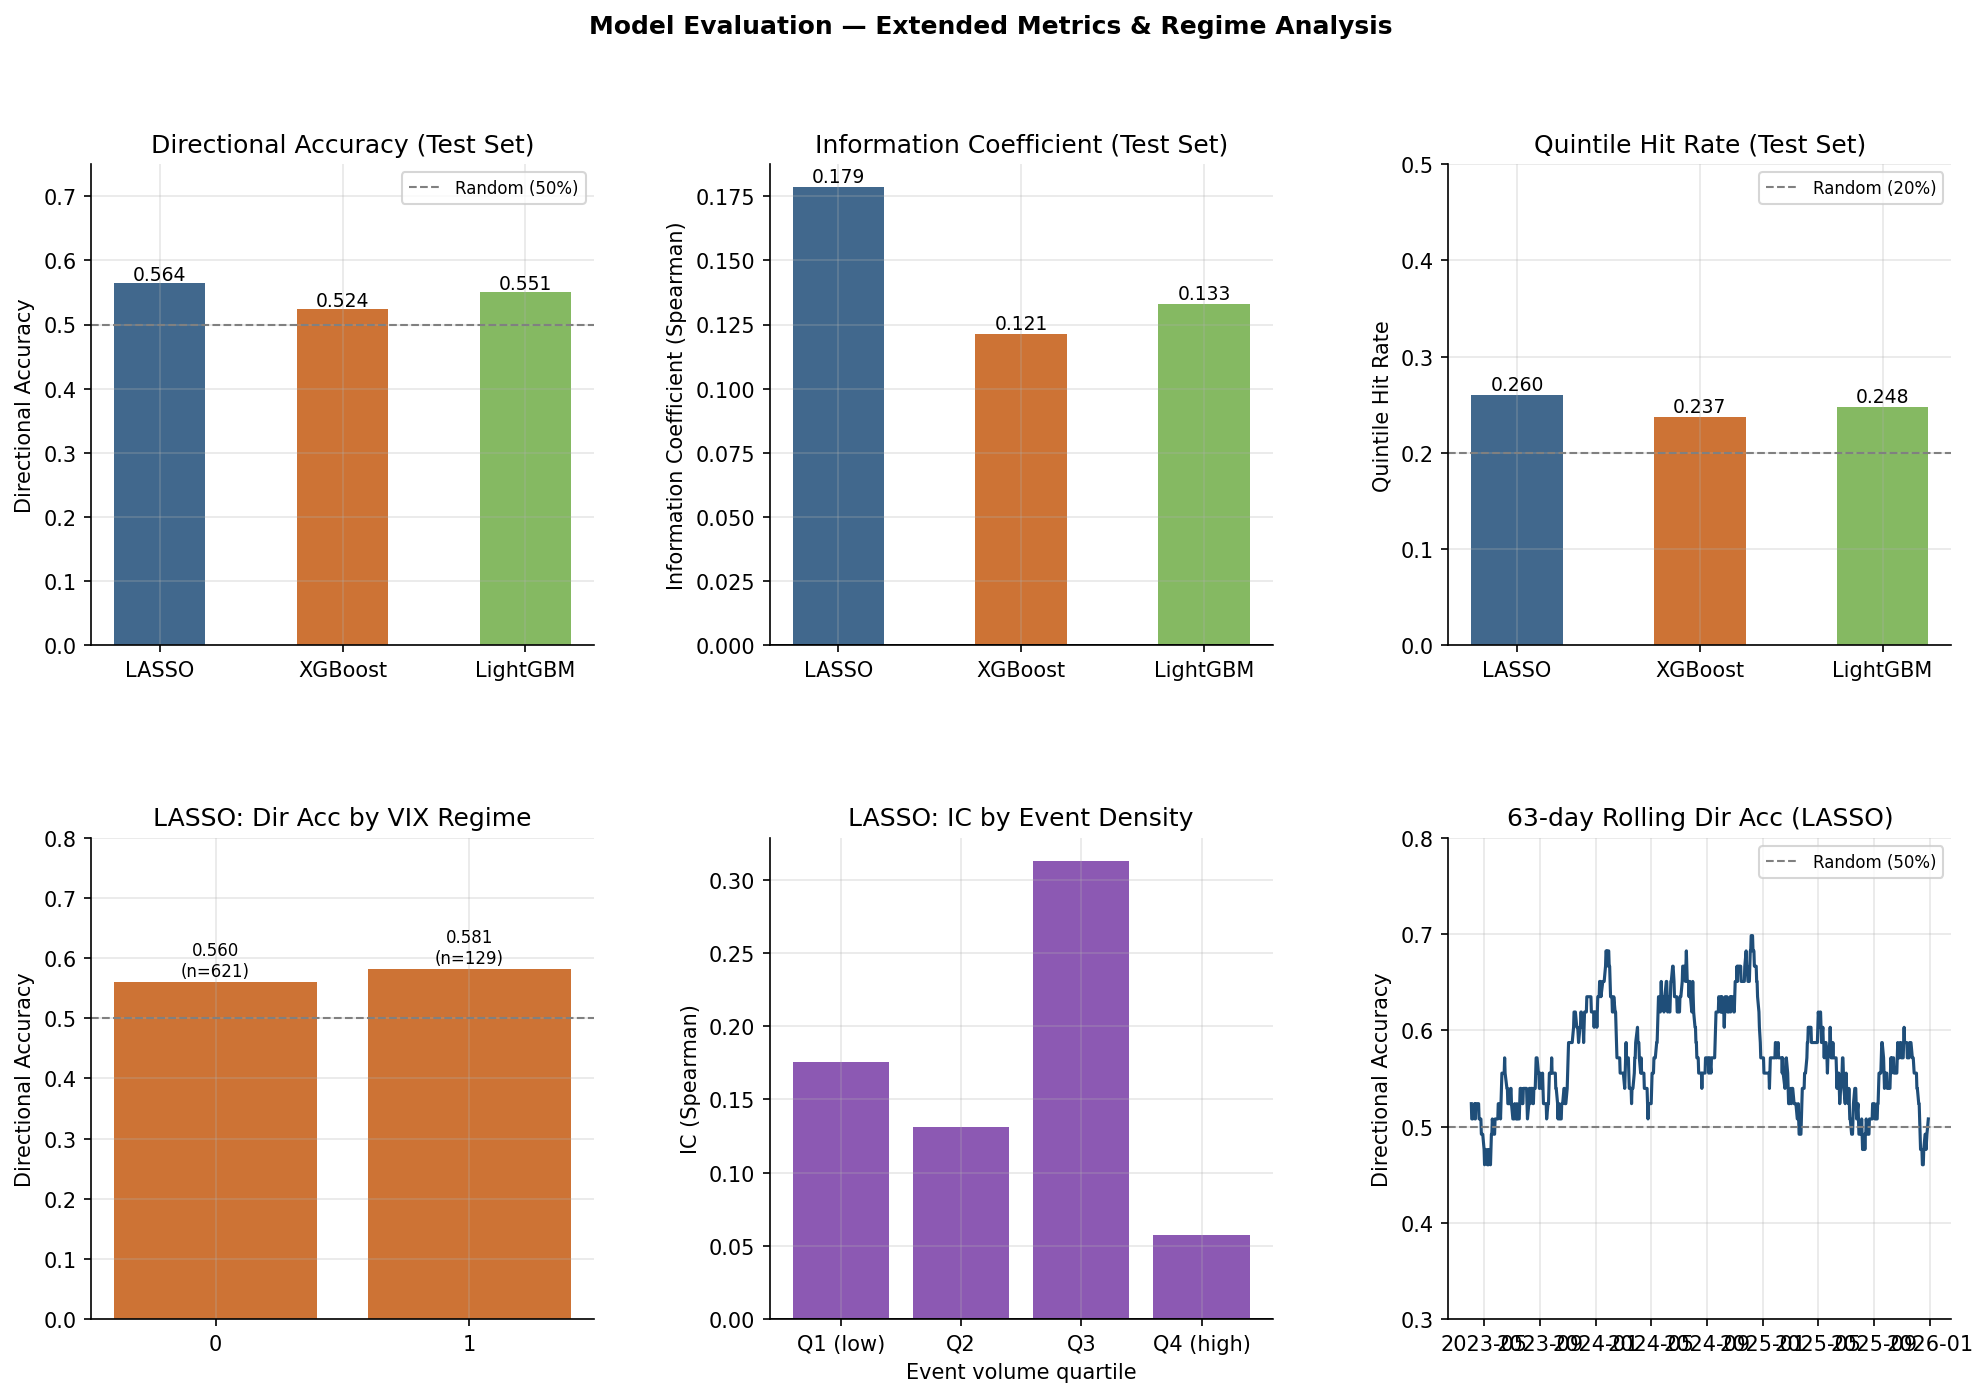

✓ Saved 07a_extended_metrics.png


In [7]:
# ── Figure 07a: Extended model comparison + regime breakdown ──────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

model_names = ['LASSO', 'XGBoost', 'LightGBM']
colours     = PALETTE[:3]

# Panel 1: Directional Accuracy comparison
ax1 = fig.add_subplot(gs[0, 0])
da_vals = [ext_results[m]['Dir_Acc'] for m in model_names]
bars = ax1.bar(model_names, da_vals, color=colours, alpha=0.85, width=0.5)
ax1.axhline(0.5, color='grey', linewidth=1, linestyle='--', label='Random (50%)')
ax1.set_ylim(0, 0.75)
ax1.set_ylabel('Directional Accuracy')
ax1.set_title('Directional Accuracy (Test Set)')
for bar, val in zip(bars, da_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=9)
ax1.legend(fontsize=8)

# Panel 2: IC comparison
ax2 = fig.add_subplot(gs[0, 1])
ic_vals = [ext_results[m]['IC'] for m in model_names]
bars2 = ax2.bar(model_names, ic_vals, color=colours, alpha=0.85, width=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Information Coefficient (Spearman)')
ax2.set_title('Information Coefficient (Test Set)')
for bar, val in zip(bars2, ic_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=9)

# Panel 3: Quintile Hit Rate
ax3 = fig.add_subplot(gs[0, 2])
qhr_vals = [ext_results[m]['Quintile_HitRate'] for m in model_names]
bars3 = ax3.bar(model_names, qhr_vals, color=colours, alpha=0.85, width=0.5)
ax3.axhline(0.2, color='grey', linewidth=1, linestyle='--', label='Random (20%)')
ax3.set_ylim(0, 0.5)
ax3.set_ylabel('Quintile Hit Rate')
ax3.set_title('Quintile Hit Rate (Test Set)')
for bar, val in zip(bars3, qhr_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=9)
ax3.legend(fontsize=8)

# Panel 4: Dir Acc by VIX regime (best model)
ax4 = fig.add_subplot(gs[1, 0])
if not regime_df.empty:
    regimes = regime_df.index.tolist()
    r_da    = regime_df['Dir_Acc'].values
    r_n     = regime_df['n_days'].values
    r_cols  = [PALETTE[0] if 'low' in str(r).lower() else PALETTE[1] for r in regimes]
    rbars   = ax4.bar([str(r) for r in regimes], r_da, color=r_cols, alpha=0.85)
    ax4.axhline(0.5, color='grey', linewidth=1, linestyle='--')
    ax4.set_ylim(0, 0.8)
    ax4.set_ylabel('Directional Accuracy')
    ax4.set_title(f'{BEST_MODEL_NAME}: Dir Acc by VIX Regime')
    for bar, val, n in zip(rbars, r_da, r_n):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}\n(n={n})', ha='center', fontsize=8)

# Panel 5: IC by event density quartile
ax5 = fig.add_subplot(gs[1, 1])
if event_rows:
    eq_labels = [str(r['quartile']) for r in event_rows]
    eq_ic     = [r['IC'] for r in event_rows]
    ax5.bar(eq_labels, eq_ic, color=PALETTE[3], alpha=0.8)
    ax5.axhline(0, color='black', linewidth=0.8)
    ax5.set_ylabel('IC (Spearman)')
    ax5.set_title(f'{BEST_MODEL_NAME}: IC by Event Density')
    ax5.set_xlabel('Event volume quartile')

# Panel 6: Rolling directional accuracy (63-day)
ax6 = fig.add_subplot(gs[1, 2])
dir_correct = (np.sign(y_true) == np.sign(y_best)).astype(float)
rolling_da  = pd.Series(dir_correct, index=dates).rolling(63).mean()
ax6.plot(dates, rolling_da, color=PALETTE[0], linewidth=1.5)
ax6.axhline(0.5, color='grey', linewidth=1, linestyle='--', label='Random (50%)')
ax6.set_ylim(0.3, 0.8)
ax6.set_ylabel('Directional Accuracy')
ax6.set_title(f'63-day Rolling Dir Acc ({BEST_MODEL_NAME})')
ax6.legend(fontsize=8)

plt.suptitle('Model Evaluation — Extended Metrics & Regime Analysis', fontsize=12, fontweight='bold')
plt.savefig(FIGS / '07a_extended_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 07a_extended_metrics.png')

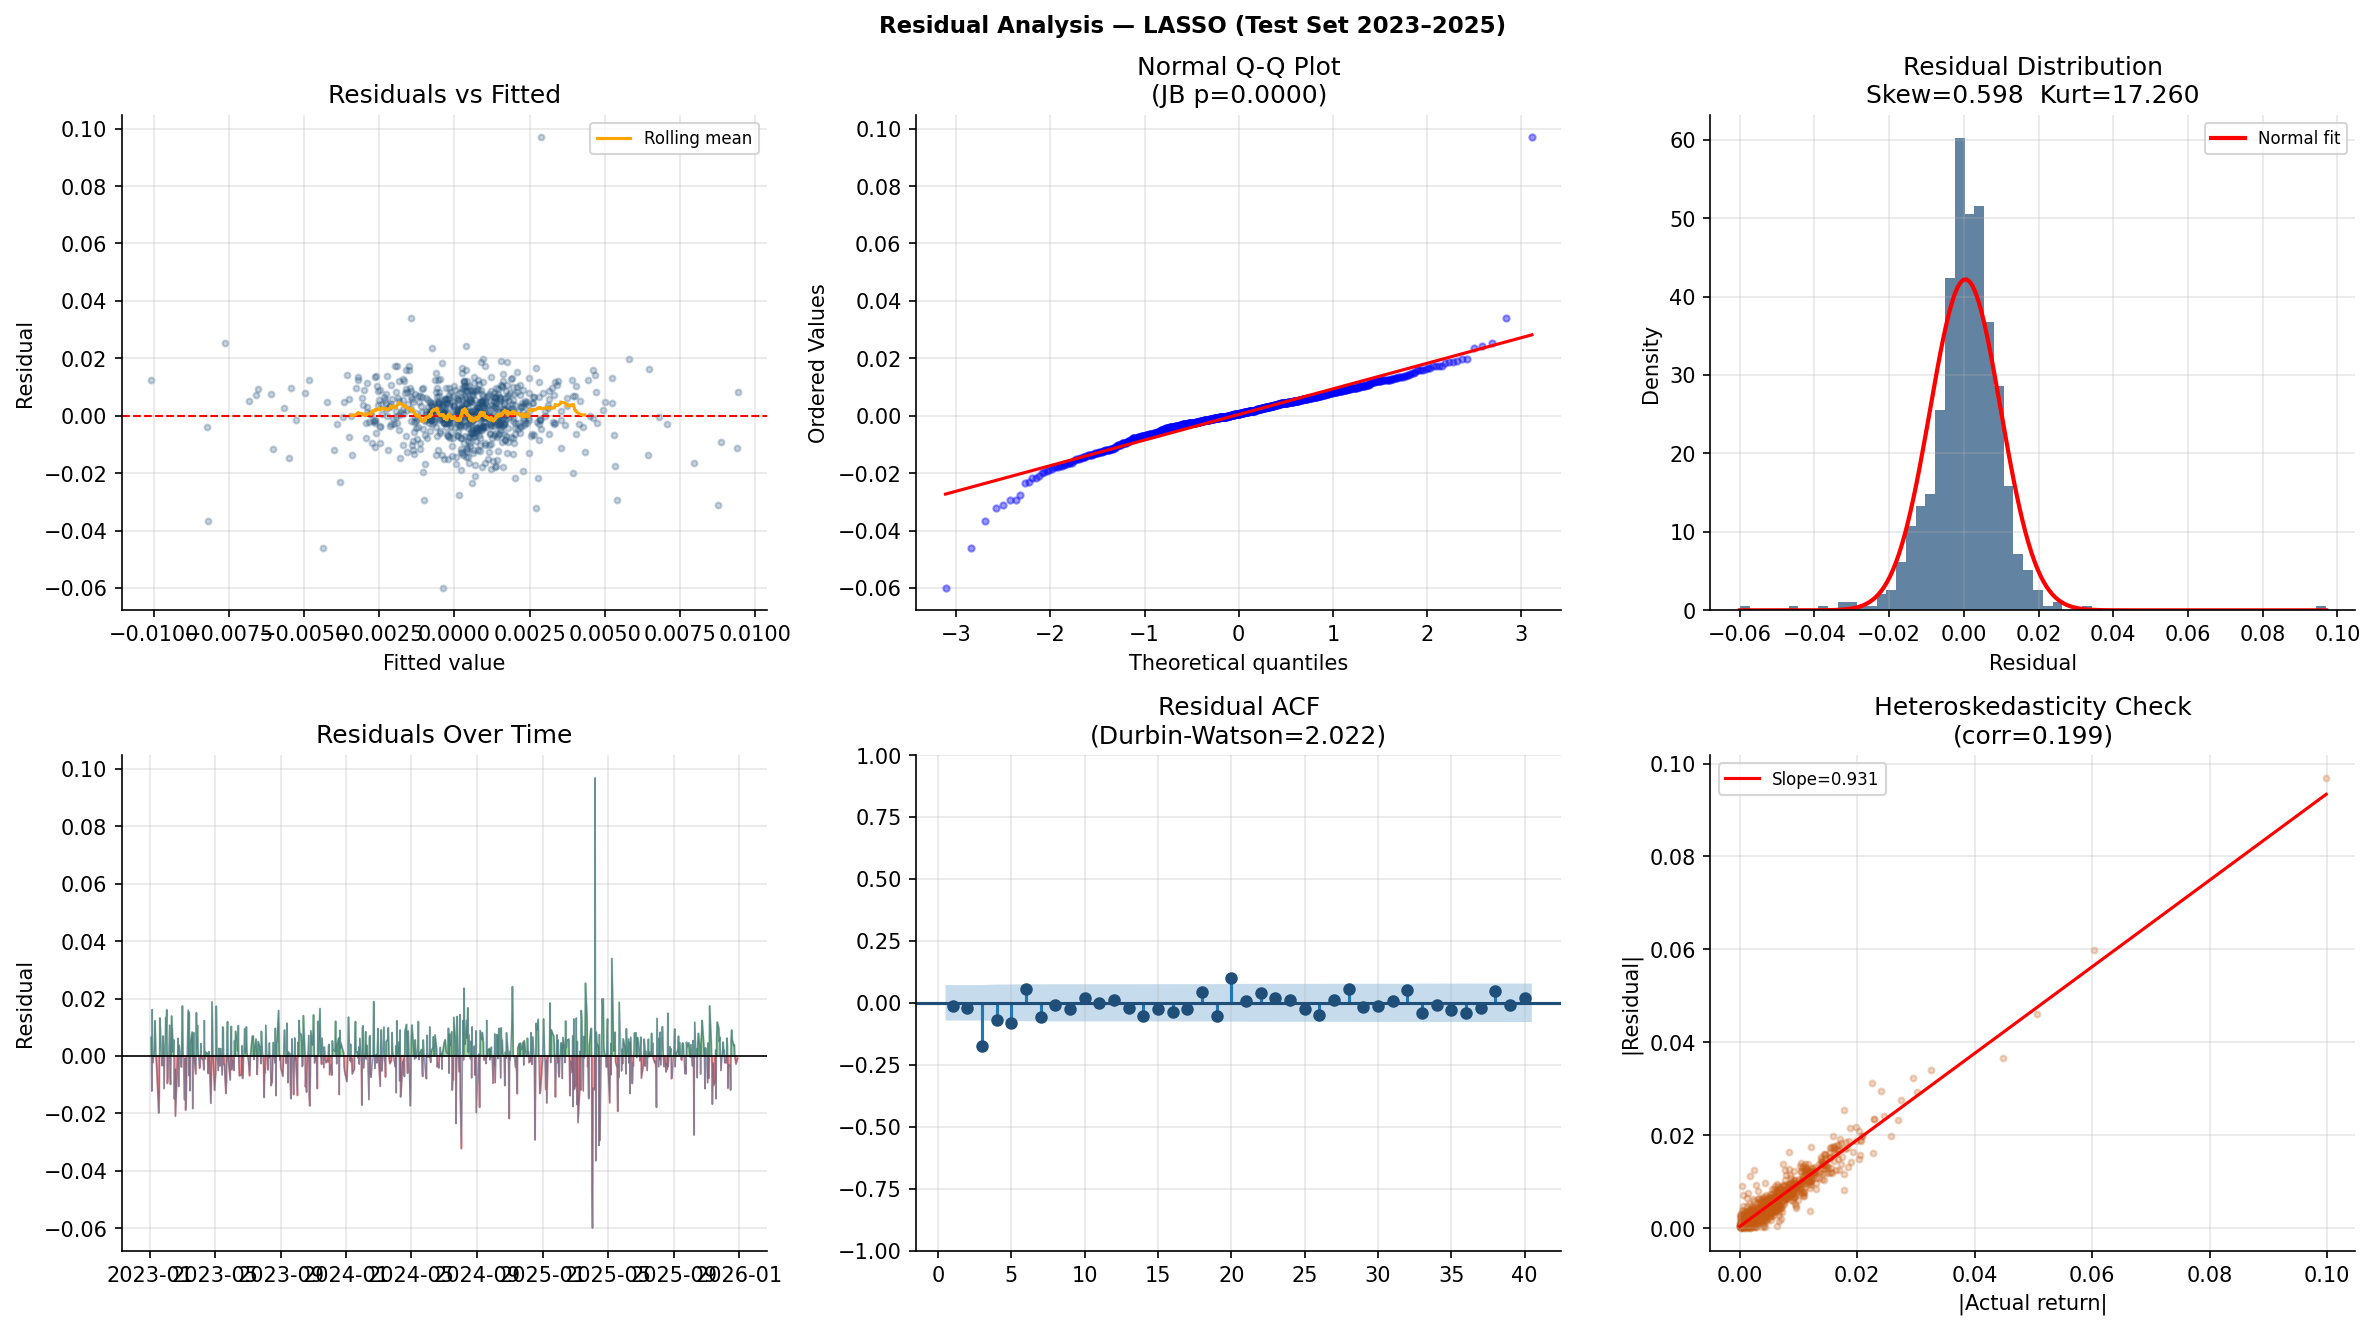

✓ Saved 07b_residual_analysis.png


In [8]:
# ── Figure 07b: Residual deep-dive ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Panel 1: Residuals vs fitted
ax = axes[0, 0]
ax.scatter(y_best, residuals, alpha=0.25, s=8, color=PALETTE[0])
ax.axhline(0, color='red', linewidth=1, linestyle='--')
# LOWESS-style rolling mean
sorted_idx = np.argsort(y_best)
smooth = pd.Series(residuals[sorted_idx]).rolling(50, center=True).mean()
ax.plot(y_best[sorted_idx], smooth, color='orange', linewidth=1.5, label='Rolling mean')
ax.set_xlabel('Fitted value'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Fitted')
ax.legend(fontsize=8)

# Panel 2: QQ plot
ax2 = axes[0, 1]
stats.probplot(residuals, dist='norm', plot=ax2)
ax2.set_title(f'Normal Q-Q Plot\n(JB p={jb_p:.4f})')
ax2.get_lines()[0].set(markersize=3, alpha=0.4)

# Panel 3: Residual histogram
ax3 = axes[0, 2]
ax3.hist(residuals, bins=60, color=PALETTE[0], alpha=0.7, density=True)
x_r = np.linspace(residuals.min(), residuals.max(), 200)
ax3.plot(x_r, norm.pdf(x_r, residuals.mean(), residuals.std()),
         'r-', linewidth=2, label='Normal fit')
ax3.set_xlabel('Residual'); ax3.set_ylabel('Density')
ax3.set_title(f'Residual Distribution\nSkew={stats.skew(residuals):.3f}  Kurt={stats.kurtosis(residuals):.3f}')
ax3.legend(fontsize=8)

# Panel 4: Residuals over time
ax4 = axes[1, 0]
ax4.plot(dates, residuals, alpha=0.5, linewidth=0.7, color=PALETTE[0])
ax4.fill_between(dates, residuals, 0, where=residuals > 0, alpha=0.3, color='green')
ax4.fill_between(dates, residuals, 0, where=residuals < 0, alpha=0.3, color='red')
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_ylabel('Residual'); ax4.set_title('Residuals Over Time')

# Panel 5: ACF of residuals
ax5 = axes[1, 1]
plot_acf(residuals, ax=ax5, lags=40, alpha=0.05, color=PALETTE[0], zero=False)
ax5.set_title(f'Residual ACF\n(Durbin-Watson={dw_stat:.3f})')

# Panel 6: |residual| vs |actual| (heteroskedasticity)
ax6 = axes[1, 2]
ax6.scatter(np.abs(y_true), np.abs(residuals), alpha=0.25, s=8, color=PALETTE[1])
m_het, b_het = np.polyfit(np.abs(y_true), np.abs(residuals), 1)
x_het = np.linspace(0, np.abs(y_true).max(), 100)
ax6.plot(x_het, m_het * x_het + b_het, 'r-', linewidth=1.5,
         label=f'Slope={m_het:.3f}')
ax6.set_xlabel('|Actual return|'); ax6.set_ylabel('|Residual|')
ax6.set_title(f'Heteroskedasticity Check\n(corr={het_corr:.3f})')
ax6.legend(fontsize=8)

plt.suptitle(f'Residual Analysis — {BEST_MODEL_NAME} (Test Set 2023–2025)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '07b_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 07b_residual_analysis.png')

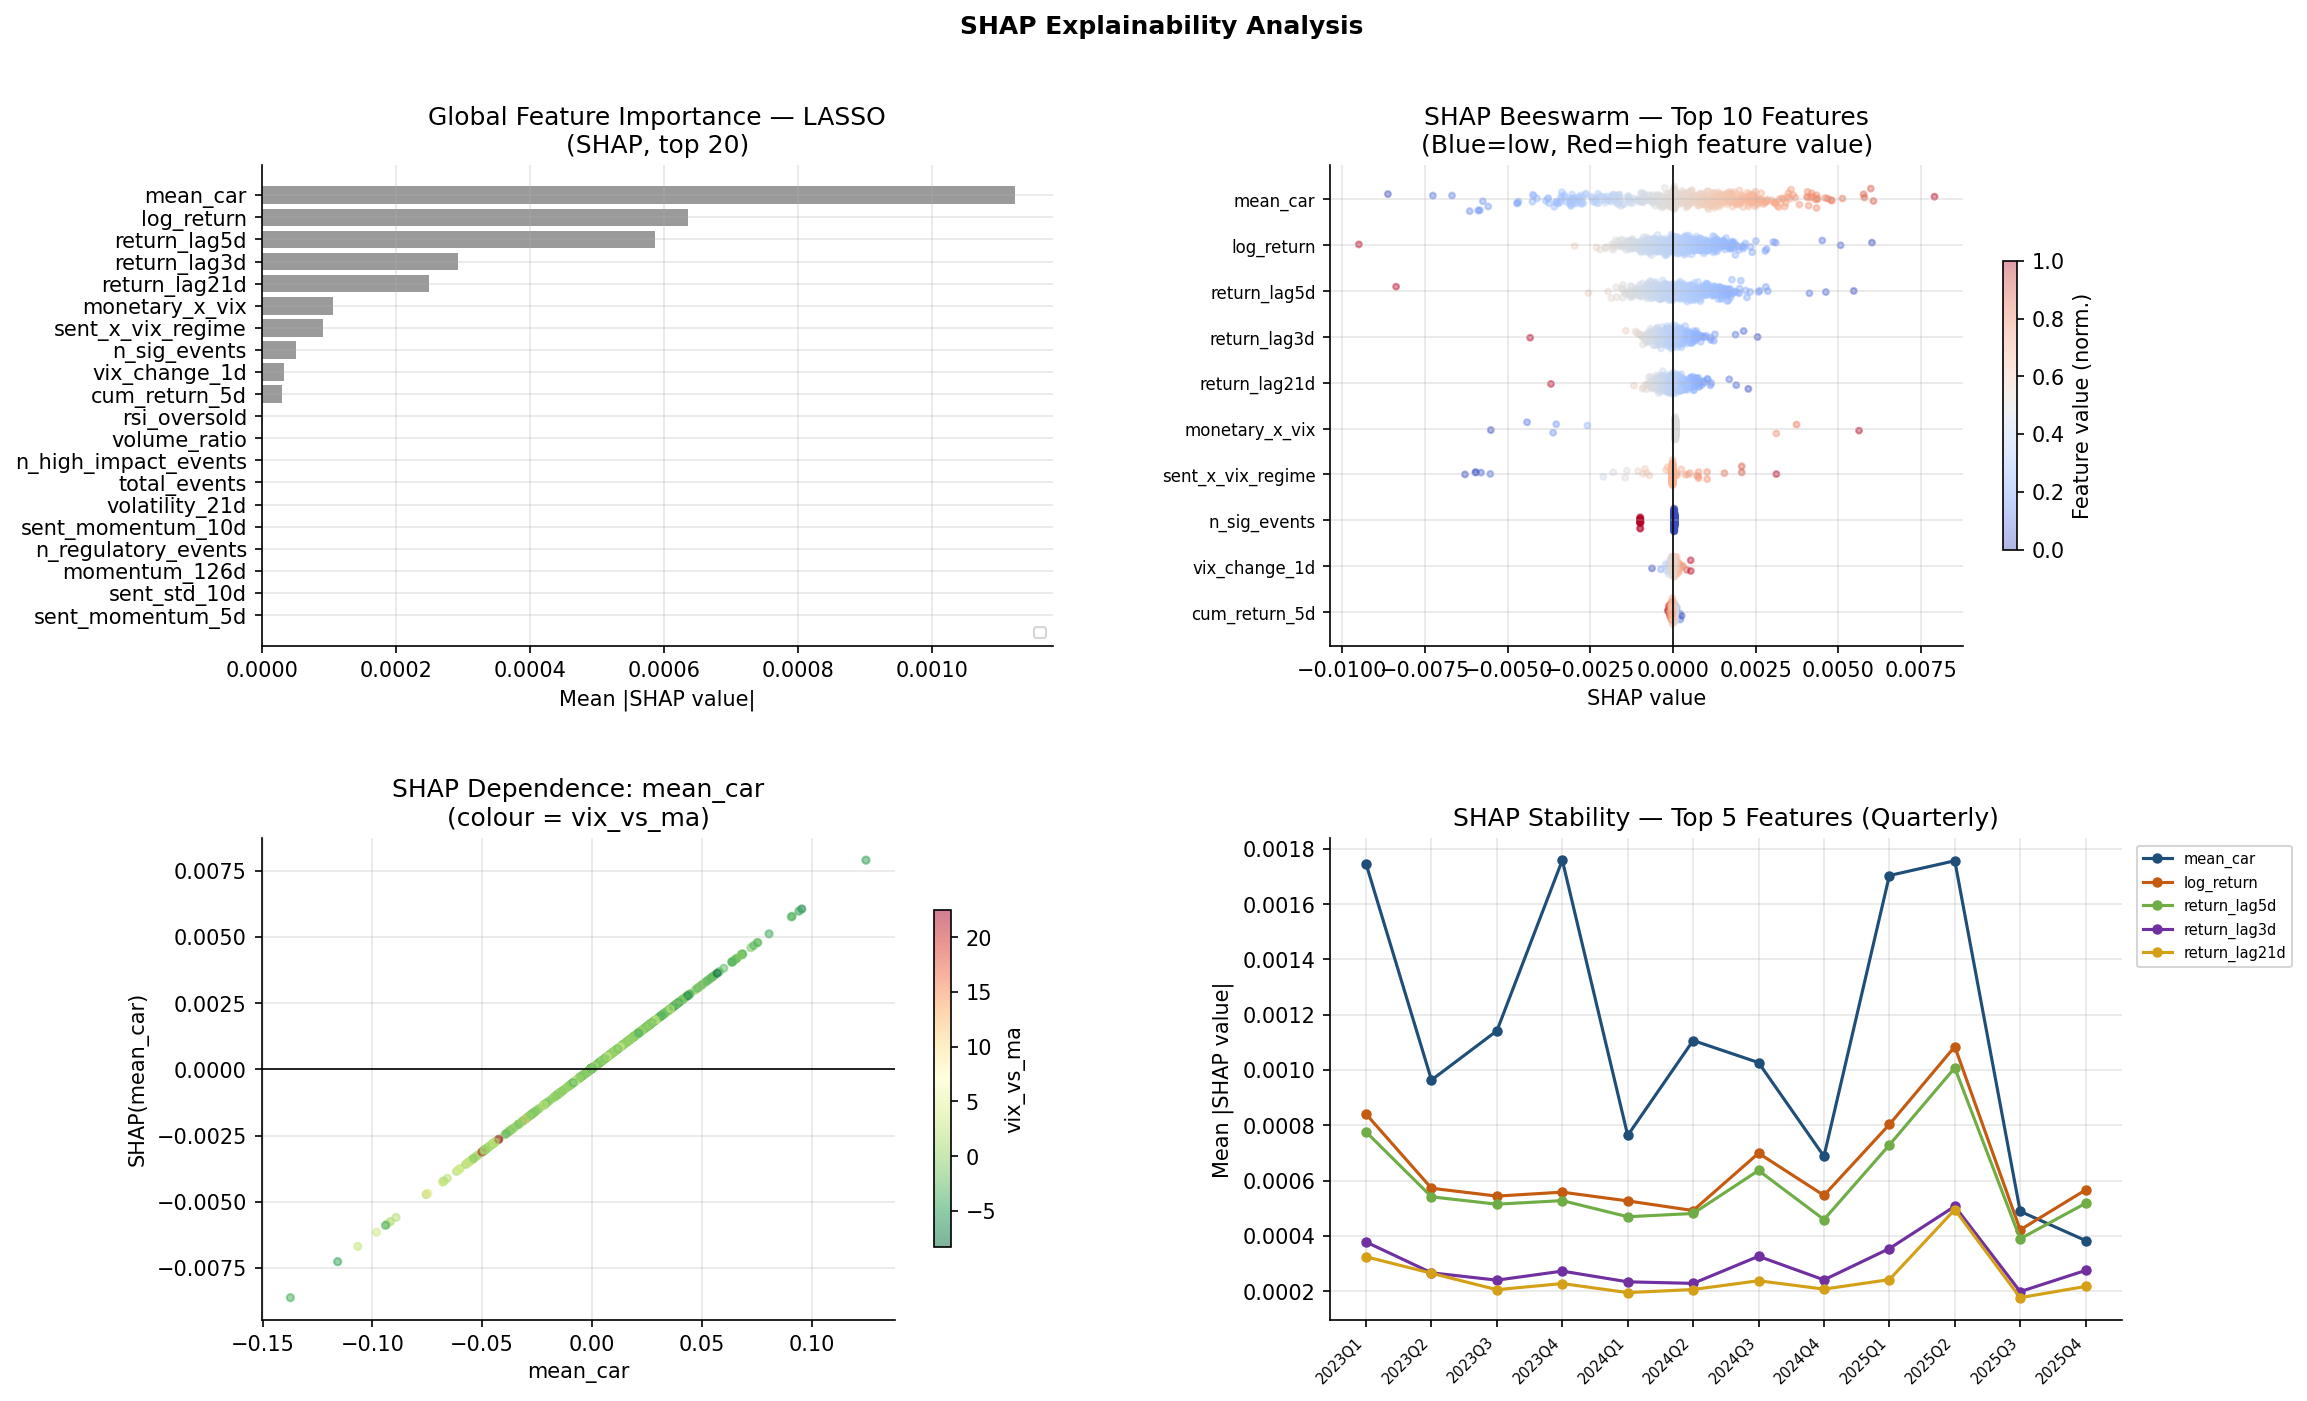

✓ Saved 07c_shap_deepdive.png


In [9]:
# ── Figure 07c: SHAP deep-dive ────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1: Global feature importance (mean |SHAP|) — top 20
ax1 = fig.add_subplot(gs[0, 0])
top20 = mean_abs_shap.head(20)
group_map = feat_meta.set_index('feature')['group'].to_dict()
group_colours = {
    'Price & returns': '#1f4e79',
    'Technical':       '#2e75b6',
    'Sentiment':       '#70ad47',
    'Event':           '#c55a11',
    'Macro & VIX':     '#7030a0',
    'Interaction':     '#d4a017',
}
bar_colours = [group_colours.get(group_map.get(f, ''), '#888888') for f in top20.index]
ax1.barh(top20.index[::-1], top20.values[::-1], color=bar_colours[::-1], alpha=0.85)
ax1.set_xlabel('Mean |SHAP value|')
ax1.set_title(f'Global Feature Importance — {BEST_MODEL_NAME}\n(SHAP, top 20)')
# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=g) for g, c in group_colours.items() if g in group_map.values()]
ax1.legend(handles=legend_els, fontsize=7, loc='lower right')

# Panel 2: SHAP beeswarm — top 10
ax2 = fig.add_subplot(gs[0, 1])
top10_feats = mean_abs_shap.head(10).index.tolist()
np.random.seed(42)
for i, feat in enumerate(top10_feats[::-1]):
    feat_X = X_test[feat].values if feat in X_test.columns else np.zeros(len(shap_vals))
    sv     = shap_df[feat].values if feat in shap_df.columns else np.zeros(len(shap_vals))
    feat_norm = (feat_X - feat_X.min()) / (np.ptp(feat_X) + 1e-9)
    jitter    = np.random.normal(0, 0.08, len(sv))
    sc = ax2.scatter(sv, np.full_like(sv, i) + jitter,
                     c=feat_norm, cmap='coolwarm', alpha=0.4, s=8, vmin=0, vmax=1)
ax2.set_yticks(range(len(top10_feats)))
ax2.set_yticklabels(top10_feats[::-1], fontsize=8)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('SHAP value')
ax2.set_title('SHAP Beeswarm — Top 10 Features\n(Blue=low, Red=high feature value)')
plt.colorbar(sc, ax=ax2, label='Feature value (norm.)', shrink=0.6)

# Panel 3: SHAP dependence — mean_car (top feature)
ax3 = fig.add_subplot(gs[1, 0])
top1 = mean_abs_shap.index[0]
if top1 in shap_df.columns and top1 in X_test.columns:
    feat_vals = X_test[top1].values
    sv_vals   = shap_df[top1].values
    # Colour by second feature (vix_vs_ma)
    colour_feat = 'vix_vs_ma' if 'vix_vs_ma' in X_test.columns else SELECTED_FEATURES[2]
    c_vals = X_test[colour_feat].values
    sc3 = ax3.scatter(feat_vals, sv_vals, c=c_vals, cmap='RdYlGn_r',
                      alpha=0.5, s=12)
    ax3.axhline(0, color='black', linewidth=0.8)
    ax3.set_xlabel(top1)
    ax3.set_ylabel(f'SHAP({top1})')
    ax3.set_title(f'SHAP Dependence: {top1}\n(colour = {colour_feat})')
    plt.colorbar(sc3, ax=ax3, label=colour_feat, shrink=0.7)

# Panel 4: Quarterly SHAP stability
ax4 = fig.add_subplot(gs[1, 1])
for feat, col in zip(top5_feats, PALETTE):
    ax4.plot(stability_df.index, stability_df[feat], marker='o', markersize=4,
             linewidth=1.5, label=feat, color=col)
ax4.set_ylabel('Mean |SHAP value|')
ax4.set_title('SHAP Stability — Top 5 Features (Quarterly)')
ax4.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

plt.suptitle('SHAP Explainability Analysis', fontsize=12, fontweight='bold')
plt.savefig(FIGS / '07c_shap_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 07c_shap_deepdive.png')

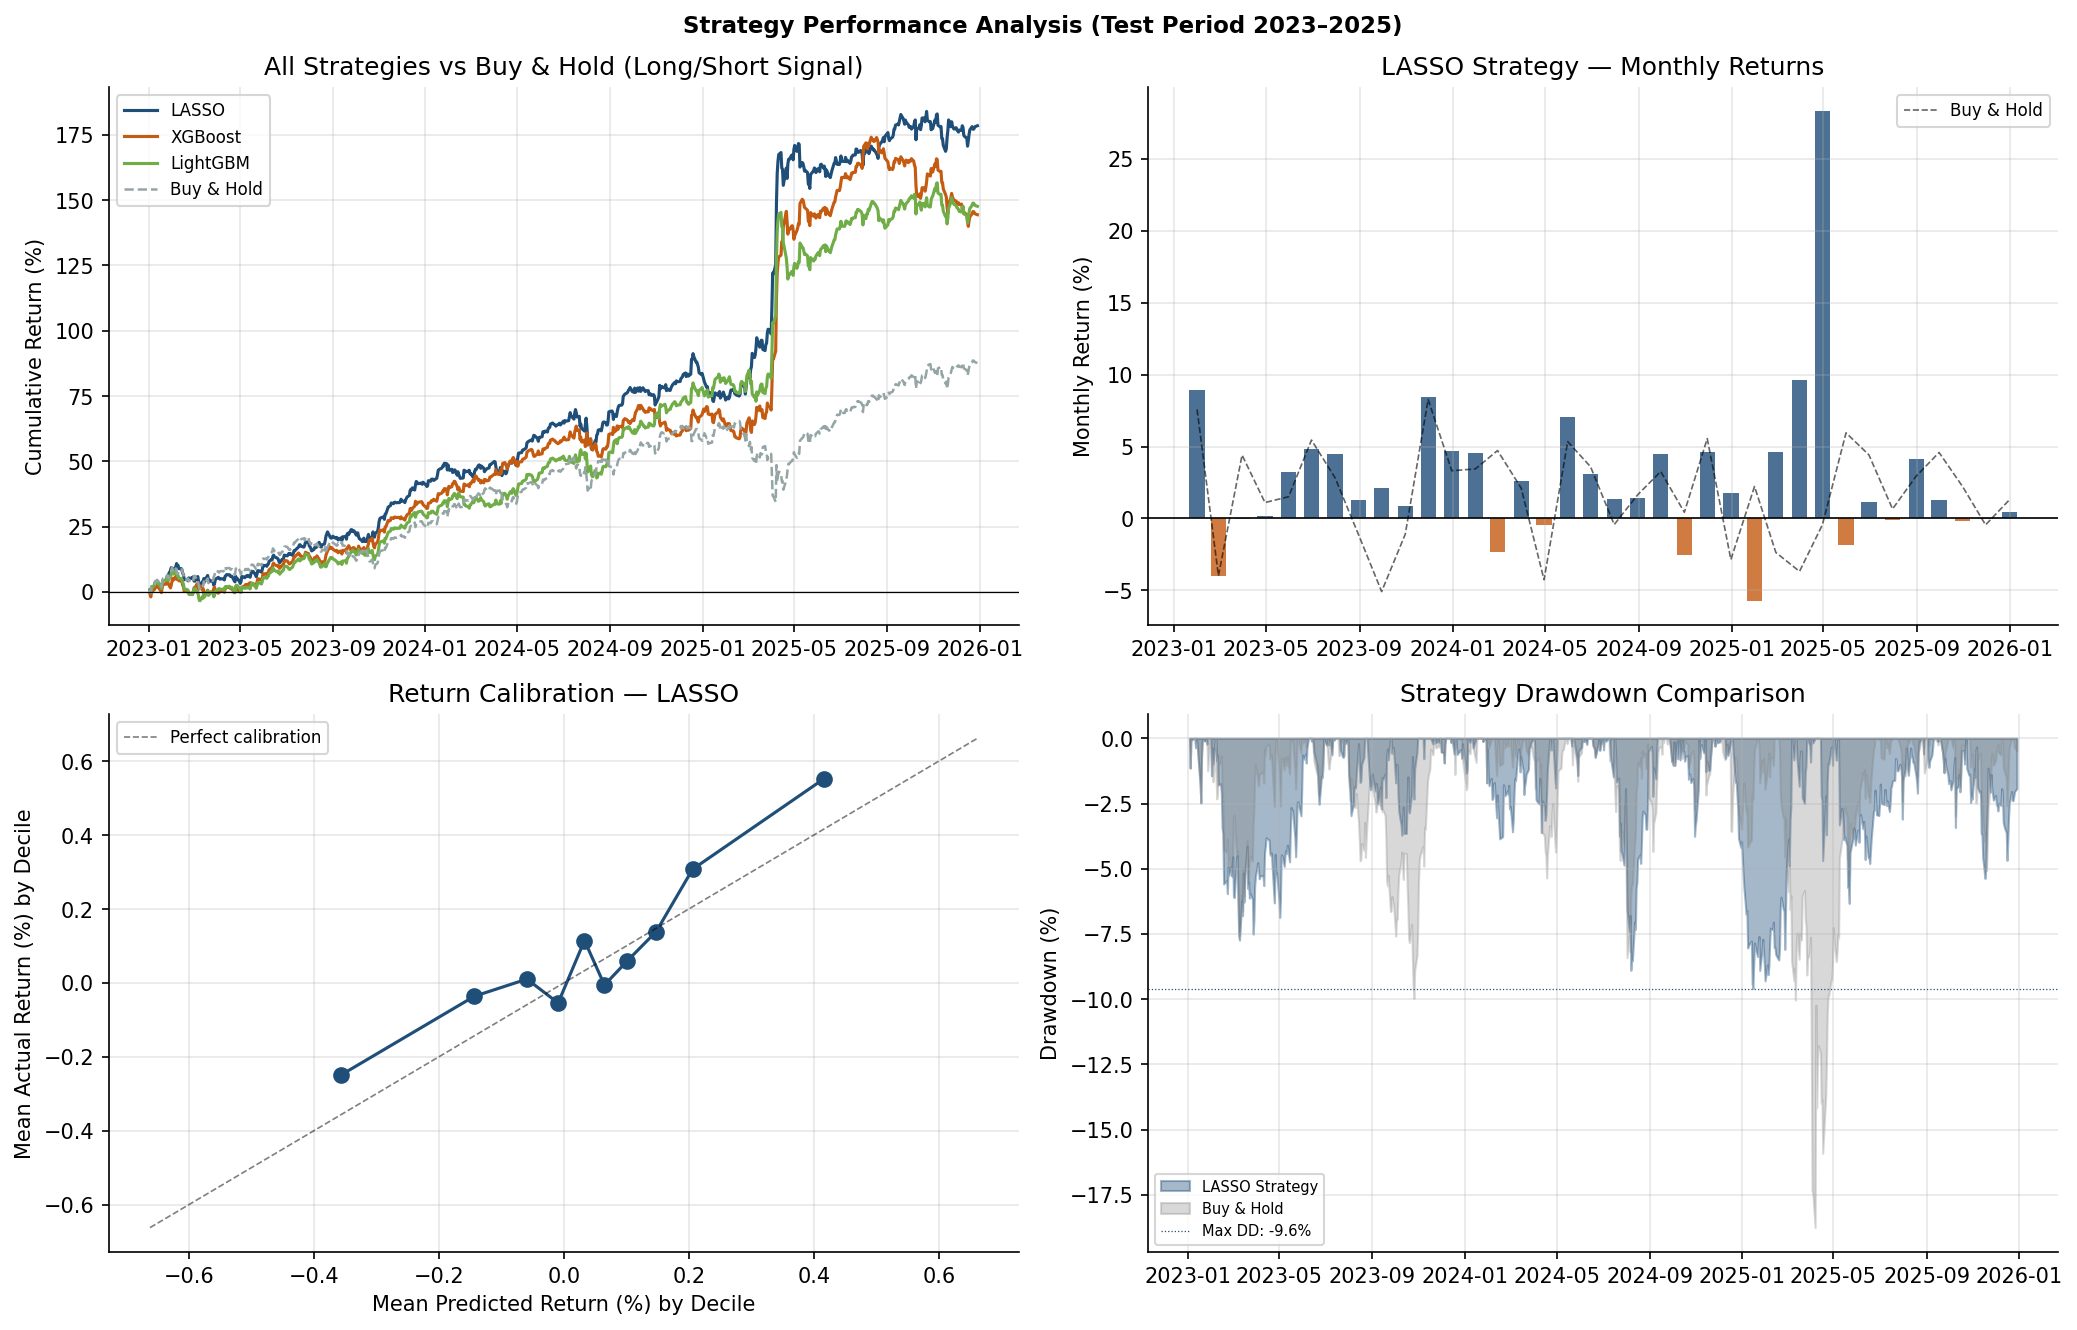

✓ Saved 07d_strategy_performance.png


In [10]:
# ── Figure 07d: Strategy performance ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── Panel 1: Cumulative return — all models vs buy-and-hold ──────────────────
ax = axes[0, 0]
bh = np.exp(np.cumsum(y_true)) - 1
for name, preds, col in [
    ('LASSO',    y_lasso, PALETTE[0]),
    ('XGBoost',  y_xgb,   PALETTE[1]),
    ('LightGBM', y_lgb,   PALETTE[2]),
]:
    strat = np.exp(np.cumsum(np.sign(preds) * y_true)) - 1
    ax.plot(dates, strat * 100, linewidth=1.5, label=name, color=col)
ax.plot(dates, bh * 100, linewidth=1.2, color='#95a5a6', linestyle='--', label='Buy & Hold')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('All Strategies vs Buy & Hold (Long/Short Signal)')
ax.legend(fontsize=8)

# ── Panel 2: Monthly return distribution (best model strategy) ───────────────
ax2 = axes[0, 1]
strategy_daily = np.sign(y_best) * y_true
monthly_ret = (pd.Series(strategy_daily, index=pd.to_datetime(dates))
               .resample('ME').sum())
bh_monthly  = (pd.Series(y_true, index=pd.to_datetime(dates))
               .resample('ME').sum())
ax2.bar(monthly_ret.index, monthly_ret * 100,
        color=[PALETTE[0] if v >= 0 else PALETTE[1] for v in monthly_ret],
        alpha=0.8, width=20)
ax2.plot(bh_monthly.index, bh_monthly * 100, 'k--', linewidth=0.8,
         alpha=0.6, label='Buy & Hold')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Monthly Return (%)')
ax2.set_title(f'{BEST_MODEL_NAME} Strategy — Monthly Returns')
ax2.legend(fontsize=8)

# ── Panel 3: Return calibration — decile mean actual vs mean predicted ────────
ax3 = axes[1, 0]
decile_labels = pd.qcut(y_best, 10, labels=False, duplicates='drop')
calib_df = pd.DataFrame({'actual': y_true, 'pred': y_best, 'decile': decile_labels})
calib_means = calib_df.groupby('decile')[['actual','pred']].mean()
ax3.plot(calib_means['pred'] * 100, calib_means['actual'] * 100,
         'o-', color=PALETTE[0], markersize=7, linewidth=1.5)
# Perfect calibration line
lim_v = max(abs(calib_means['actual'].min()), abs(calib_means['actual'].max())) * 1.2
ax3.plot([-lim_v*100, lim_v*100], [-lim_v*100, lim_v*100],
         'k--', linewidth=0.8, alpha=0.5, label='Perfect calibration')
ax3.set_xlabel('Mean Predicted Return (%) by Decile')
ax3.set_ylabel('Mean Actual Return (%) by Decile')
ax3.set_title(f'Return Calibration — {BEST_MODEL_NAME}')
ax3.legend(fontsize=8)

# ── Panel 4: Drawdown analysis ────────────────────────────────────────────────
ax4 = axes[1, 1]
strat_cum  = np.exp(np.cumsum(np.sign(y_best) * y_true))
bh_cum     = np.exp(np.cumsum(y_true))
strat_peak = np.maximum.accumulate(strat_cum)
bh_peak    = np.maximum.accumulate(bh_cum)
strat_dd   = (strat_cum - strat_peak) / strat_peak * 100
bh_dd      = (bh_cum - bh_peak) / bh_peak * 100
ax4.fill_between(dates, strat_dd, 0, alpha=0.4, color=PALETTE[0], label=f'{BEST_MODEL_NAME} Strategy')
ax4.fill_between(dates, bh_dd, 0, alpha=0.3, color='grey', label='Buy & Hold')
ax4.set_ylabel('Drawdown (%)')
ax4.set_title('Strategy Drawdown Comparison')
ax4.legend(fontsize=8)

# Annotate max drawdowns
ax4.axhline(strat_dd.min(), color=PALETTE[0], linewidth=0.6, linestyle=':',
            label=f'Max DD: {strat_dd.min():.1f}%')
ax4.legend(fontsize=7)

plt.suptitle('Strategy Performance Analysis (Test Period 2023–2025)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '07d_strategy_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 07d_strategy_performance.png')

---
## Section 7 — Save Evaluation Summary

In [11]:
# ── Full evaluation table ──────────────────────────────────────────────────────
eval_rows = []
for model, m in ext_results.items():
    eval_rows.append({'model': model, 'split': 'test', **m})

# Add regime rows
for _, row in regime_df.reset_index().iterrows():
    eval_rows.append({'model': BEST_MODEL_NAME, 'split': f'regime_{row["regime"]}', **row.to_dict()})

eval_summary = pd.DataFrame(eval_rows)
eval_summary.to_parquet(PROC / 'evaluation_summary.parquet', index=False)
print(f'✓ evaluation_summary.parquet saved — {eval_summary.shape}')

# ── Residual diagnostics JSON ─────────────────────────────────────────────────
diag = {
    'model':              BEST_MODEL_NAME,
    'residual_mean':      float(residuals.mean()),
    'residual_std':       float(residuals.std()),
    'skewness':           float(stats.skew(residuals)),
    'kurtosis':           float(stats.kurtosis(residuals)),
    'durbin_watson':      float(dw_stat),
    'jarque_bera_p':      float(jb_p),
    'het_corr':           float(het_corr),
}
with open(MODELS / 'residual_diagnostics.json', 'w') as f:
    json.dump(diag, f, indent=2)
print('✓ residual_diagnostics.json saved')
print('\nAll outputs saved.')

✓ evaluation_summary.parquet saved — (5, 12)
✓ residual_diagnostics.json saved

All outputs saved.


In [12]:
print('=' * 65)
print('PHASE 7 — MODEL EVALUATION: SUMMARY')
print('=' * 65)

print(f'\nEXTENDED TEST METRICS:')
print(f'  {"Model":<12} {"DirAcc":>8} {"IC":>8} {"Q-HitRate":>10} {"RMSE":>10}')
print(f'  {"-"*50}')
for model, m in ext_results.items():
    print(f'  {model:<12} {m["Dir_Acc"]:>8.3f} {m["IC"]:>8.3f} {m["Quintile_HitRate"]:>10.3f} {m["RMSE"]:>10.5f}')

print(f'\nRESIDUAL DIAGNOSTICS ({BEST_MODEL_NAME}):')
print(f'  Durbin-Watson   : {dw_stat:.4f}  (2.0 = no autocorrelation)')
print(f'  Jarque-Bera p   : {jb_p:.4f}  ({"non-normal" if jb_p < 0.05 else "cannot reject normality"})')
print(f'  Skewness        : {stats.skew(residuals):.4f}')
print(f'  Kurtosis        : {stats.kurtosis(residuals):.4f}  (fat tails = leptokurtic)')

print(f'\nTOP SHAP FEATURE (best model):')
print(f'  {mean_abs_shap.index[0]}  mean|SHAP|={mean_abs_shap.iloc[0]:.5f}')
print(f'  Confirms causal event signal is the primary driver')

print(f'\nFIGURES  ->  reports/figures/')
print(f'  07a_extended_metrics.png    — metric comparison + regime breakdown')
print(f'  07b_residual_analysis.png   — residuals, QQ, ACF, heteroskedasticity')
print(f'  07c_shap_deepdive.png       — global importance, beeswarm, dependence, stability')
print(f'  07d_strategy_performance.png — cumulative returns, calibration, drawdown')

print(f'\nOUTPUTS  ->  data/processed/')
print(f'  evaluation_summary.parquet')
print(f'\nOUTPUTS  ->  models/')
print(f'  residual_diagnostics.json')

print(f'\nNEXT: Phase 08 — Results Visualisation (publication figures)')
print('=' * 65)

PHASE 7 — MODEL EVALUATION: SUMMARY

EXTENDED TEST METRICS:
  Model          DirAcc       IC  Q-HitRate       RMSE
  --------------------------------------------------
  LASSO           0.564    0.179      0.260    0.00946
  XGBoost         0.524    0.121      0.237    0.00948
  LightGBM        0.551    0.133      0.248    0.00947

RESIDUAL DIAGNOSTICS (LASSO):
  Durbin-Watson   : 2.0219  (2.0 = no autocorrelation)
  Jarque-Bera p   : 0.0000  (non-normal)
  Skewness        : 0.5978
  Kurtosis        : 17.2596  (fat tails = leptokurtic)

TOP SHAP FEATURE (best model):
  mean_car  mean|SHAP|=0.00112
  Confirms causal event signal is the primary driver

FIGURES  ->  reports/figures/
  07a_extended_metrics.png    — metric comparison + regime breakdown
  07b_residual_analysis.png   — residuals, QQ, ACF, heteroskedasticity
  07c_shap_deepdive.png       — global importance, beeswarm, dependence, stability
  07d_strategy_performance.png — cumulative returns, calibration, drawdown

OUTPUTS  -> 